# Time taken to adapt to a cocktail for all antibody combos

In [1]:
import os
import sys
import torch
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import matplotlib.patches as patches
from matplotlib.patches import Patch
import itertools

from tqdm import tqdm

main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils

os.chdir('../covid')
from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


e:\ESCAPE_PATHS\mean_field_theory\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\mean_field_theory\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Read results

In [2]:
PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
PROT_INIT = PROT_INIT[BEGIN:-END]


In [3]:
L=PROT_INIT.shape[0]
Q = 20

# AA proba per step, generative function method

In [4]:
D=1
BETA_AB=1


In [5]:
ab_names= list(ESCAPE_VECTORS.keys())
ab_focused = ["REGN10933", "REGN10987",'LY-CoV555','LY-CoV016']
indexes_abs = [ab_names.index(ab) for ab in ab_focused]
ab_names

['COV2-2050',
 'COV2-2082',
 'COV2-2094',
 'COV2-2096',
 'COV2-2130',
 'COV2-2165',
 'COV2-2196',
 'COV2-2479',
 'COV2-2499',
 'COV2-2677',
 'COV2-2832',
 'CR3022',
 'LY-CoV016',
 'LY-CoV555',
 'REGN10933',
 'REGN10987',
 'S2D106',
 'S2E12',
 'S2H13',
 'S2H14',
 'S2H58',
 'S2H97',
 'S2X16',
 'S2X227',
 'S2X259',
 'S2X35',
 'S2X58',
 'S304',
 'S309']

In [6]:
dir = 'results_scripts/all_cocktails'

def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    ab_parts = path.split('ab_')
    condition = ab_parts[3] if len(ab_parts) > 3 else None
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
        "condition": condition
    }



# all cocktails with REGN 10933

In [7]:

all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

all_paths = []


for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] == BETA_AB and
        params["D"] == D 
    ):
        all_paths.append(d)


def get_escape_step(filepath, ab_indices, L):
    """Compute escape step where fitness crosses 0.5"""
    mopt = np.exp(np.load(filepath+'/mopt.npy')[:, :] )
    fitness = np.prod(1 - mopt[:, ab_indices], axis=1)
    escape_step = np.argmax(fitness > 0.5) if np.any(fitness > 0.5) else len(fitness)
    return escape_step

def compute_delta_escape_steps(all_dir, ab_names, L):
    results = {}

    for fname in os.listdir(all_dir):
        if not fname.startswith(f"mean_f_free_ab_beta_ab_{BETA_AB}_D_{D}_ab_"):
            print('skipping', fname)
            continue
     

        ab_part = fname.split("ab_")[3]
        abs_involved = ab_part.split("_")
        abs_involved = [ab for ab in abs_involved if ab in ab_names]

        if len(abs_involved) < 2:
            continue  # skip single-Ab files

        cocktail_path = os.path.join(dir, fname)
        cocktail_indices = [ab_names.index(ab) for ab in abs_involved]
        cocktail_escape = get_escape_step(cocktail_path, cocktail_indices, L)

       
        results[fname] = cocktail_escape
        

    return results
cocktail_steps = compute_delta_escape_steps(dir, ab_names, L)
cocktail_steps

{'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2082': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2094': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2096': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2130': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2165': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2196': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2479': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2499': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2677': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2832': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_CR3022': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_LY-CoV016': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_LY-CoV555': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_REGN10933': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_REGN10987': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_S2D106': 11,
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_S2

In [8]:
ab_class_df_mapping=pd.read_csv('../covid/exp_data/bloom_ab_classification/ab_classification.csv')
class_mapping = ab_class_df_mapping.set_index('condition')['condition_subtype'].to_dict()#condition is antibody name, condition_subtype is class
class_mapping['VIR-7229'] = 'class 1'
class_mapping['SA55'] = 'class 4'
ab_names=list(ESCAPE_VECTORS.keys())
ab_class_df=pd.DataFrame({'antibody':ab_names})
ab_class_df['class'] = ab_class_df['antibody'].map(class_mapping)
ab_class_df

,antibody,class
0,COV2-2050,class 2
1,COV2-2082,class 4
2,COV2-2094,class 4
3,COV2-2096,class 2
4,COV2-2130,class 3
5,COV2-2165,class 1
6,COV2-2196,class 1
7,COV2-2479,class 2
8,COV2-2499,class 3
9,COV2-2677,class 4


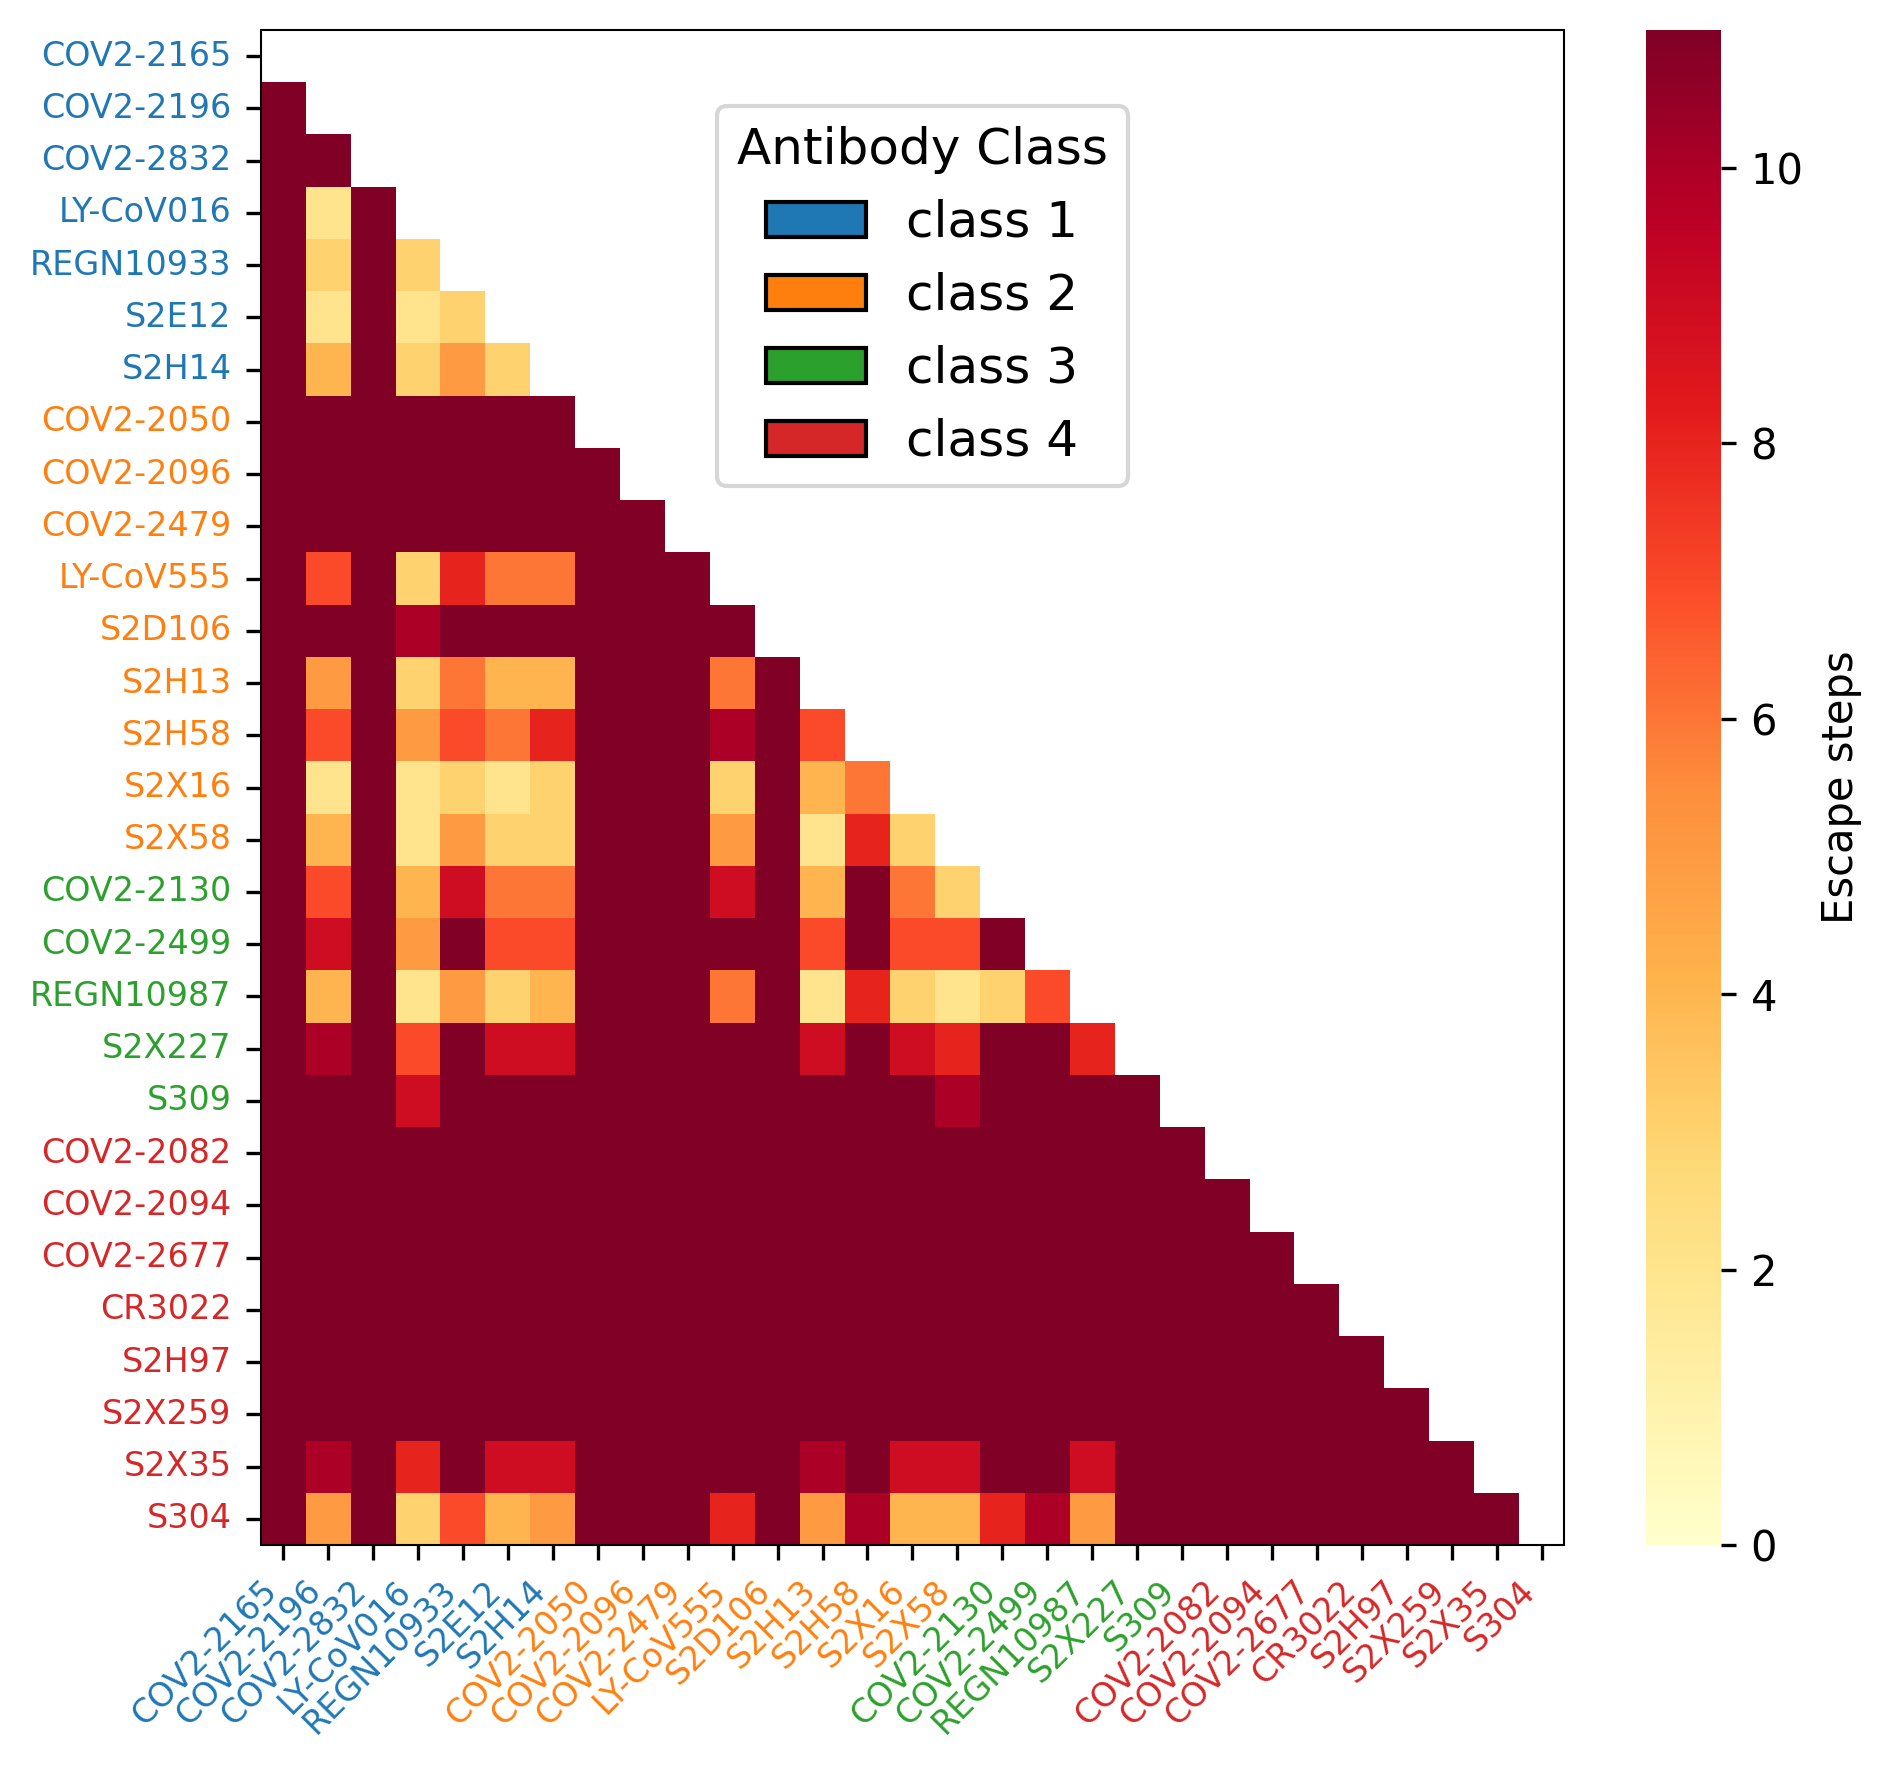

In [9]:


ab_class_df = pd.DataFrame({'antibody': ab_names})
ab_class_df['class'] = ab_class_df['antibody'].map(class_mapping).fillna('Unknown')

classes_present = list(pd.unique(ab_class_df['class']))
base_order = [f'class {i}' for i in range(1, 6)]
known = [c for c in base_order if c in classes_present]
others = [c for c in classes_present if c not in known and c != 'Unknown']
final_order = known + sorted(others) + (['Unknown'] if 'Unknown' in classes_present else [])

ab_class_df['class'] = pd.Categorical(ab_class_df['class'], categories=final_order, ordered=True)
ab_class_df_sorted = ab_class_df.sort_values(['class', 'antibody'])
sorted_ab_names = ab_class_df_sorted['antibody'].tolist()

class_colors = ab_class_df_sorted['class'].drop_duplicates().reset_index(drop=True)
color_map = {k: f"C{i}" for i, k in enumerate(class_colors)}


pair_steps = {}
pattern = re.compile(r'_ab_([^_]+)_([^_]+)$')

for k, v in cocktail_steps.items():
    m = pattern.search(k)
    if not m:
        continue
    a, b = m.group(1), m.group(2)
    if a in ab_names and b in ab_names:
        pair_steps[(a, b)] = v
        pair_steps[(b, a)] = v  # mirror to ease filling

steps_matrix = pd.DataFrame(np.nan, index=sorted_ab_names, columns=sorted_ab_names, dtype=float)
for (a, b), val in pair_steps.items():
    if a in steps_matrix.index and b in steps_matrix.columns:
        steps_matrix.at[a, b] = val

np.fill_diagonal(steps_matrix.values, np.nan)
mask = np.triu(np.ones_like(steps_matrix, dtype=bool), k=1)

plt.figure(figsize=(6.5, 6), dpi=300)

cmap = plt.get_cmap('YlOrRd').copy()
cmap.set_bad(color='white')

vmax = np.nanmax(steps_matrix.values)
ax = sns.heatmap(
    steps_matrix,
    cmap=cmap,
    vmin=0,
    vmax=vmax if np.isfinite(vmax) else None,
    mask=mask,
    xticklabels=sorted_ab_names,
    yticklabels=sorted_ab_names,
    cbar_kws={'label': 'Escape steps'}
)

highlight_abs = set()
xticks = ax.get_xticklabels()
yticks = ax.get_yticklabels()

for i, tick in enumerate(xticks):
    ab = ab_class_df_sorted.iloc[i]['antibody']
    tick.set_color(color_map[ab_class_df_sorted.iloc[i]['class']])
    if ab in highlight_abs:
        tick.set_fontweight('bold')

for i, tick in enumerate(yticks):
    ab = ab_class_df_sorted.iloc[i]['antibody']
    tick.set_color(color_map[ab_class_df_sorted.iloc[i]['class']])
    if ab in highlight_abs:
        tick.set_fontweight('bold')

ax.set_xticklabels(xticks, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(yticks, rotation=0, ha='right', fontsize=8)

legend_elements = [
    Patch(facecolor=color_map[c], edgecolor='black', label=str(c))
    for c in class_colors
]
ax.legend(
    handles=legend_elements,
    title="Antibody Class",
    bbox_to_anchor=(0.35, 0.95),
    loc='upper left',
    borderaxespad=0.,
    fontsize=12,
    title_fontsize=12
)

n = len(sorted_ab_names)
rect = patches.Rectangle(
    (0, 0), n, n,
    linewidth=0.5, edgecolor='black', facecolor='none', clip_on=False
)
ax.add_patch(rect)

plt.tight_layout()
plt.show()


In [10]:


abs_set = set(ab_names)
pair_re = re.compile(r'_ab_([^_]+)_([^_]+)$')

present = set()
unknown_key_refs = []

for k in cocktail_steps:
    m = pair_re.search(k)
    if not m:
        continue
    a, b = m.group(1), m.group(2)
    if a in abs_set and b in abs_set and a != b:
        present.add(frozenset((a, b)))
    else:
        unknown_key_refs.append((k, a, b))

expected = {frozenset(p) for p in itertools.combinations(sorted(abs_set), 2)}
missing = sorted((tuple(sorted(fs)) for fs in (expected - present)), key=lambda x: (x[0], x[1]))

print(f"Total pairs expected: {len(expected)}")
print(f"Pairs present: {len(present)}")
print(f"Missing pairs: {len(missing)}")

for a, b in missing:
    print(f"{a}, {b}")

if unknown_key_refs:
    print("\nKeys referencing antibodies not in ab_names:")
    for k, a, b in unknown_key_refs:
        print(f"{k}  ->  ({a}, {b})")


Total pairs expected: 406
Pairs present: 406
Missing pairs: 0


## Delta escape cocktail vs single ab, compared to corr wighted by MSA

In [11]:
msa_seqs=Proteins_utils.load_FASTA('../covid/RBM_artif_seq.fasta')
msa_seqs.shape

(1000, 178)

In [12]:
escapes = np.array([get_log_bindings(msa_seqs[i]) for i in range(msa_seqs.shape[0])])
escapes.shape  


(1000, 29)

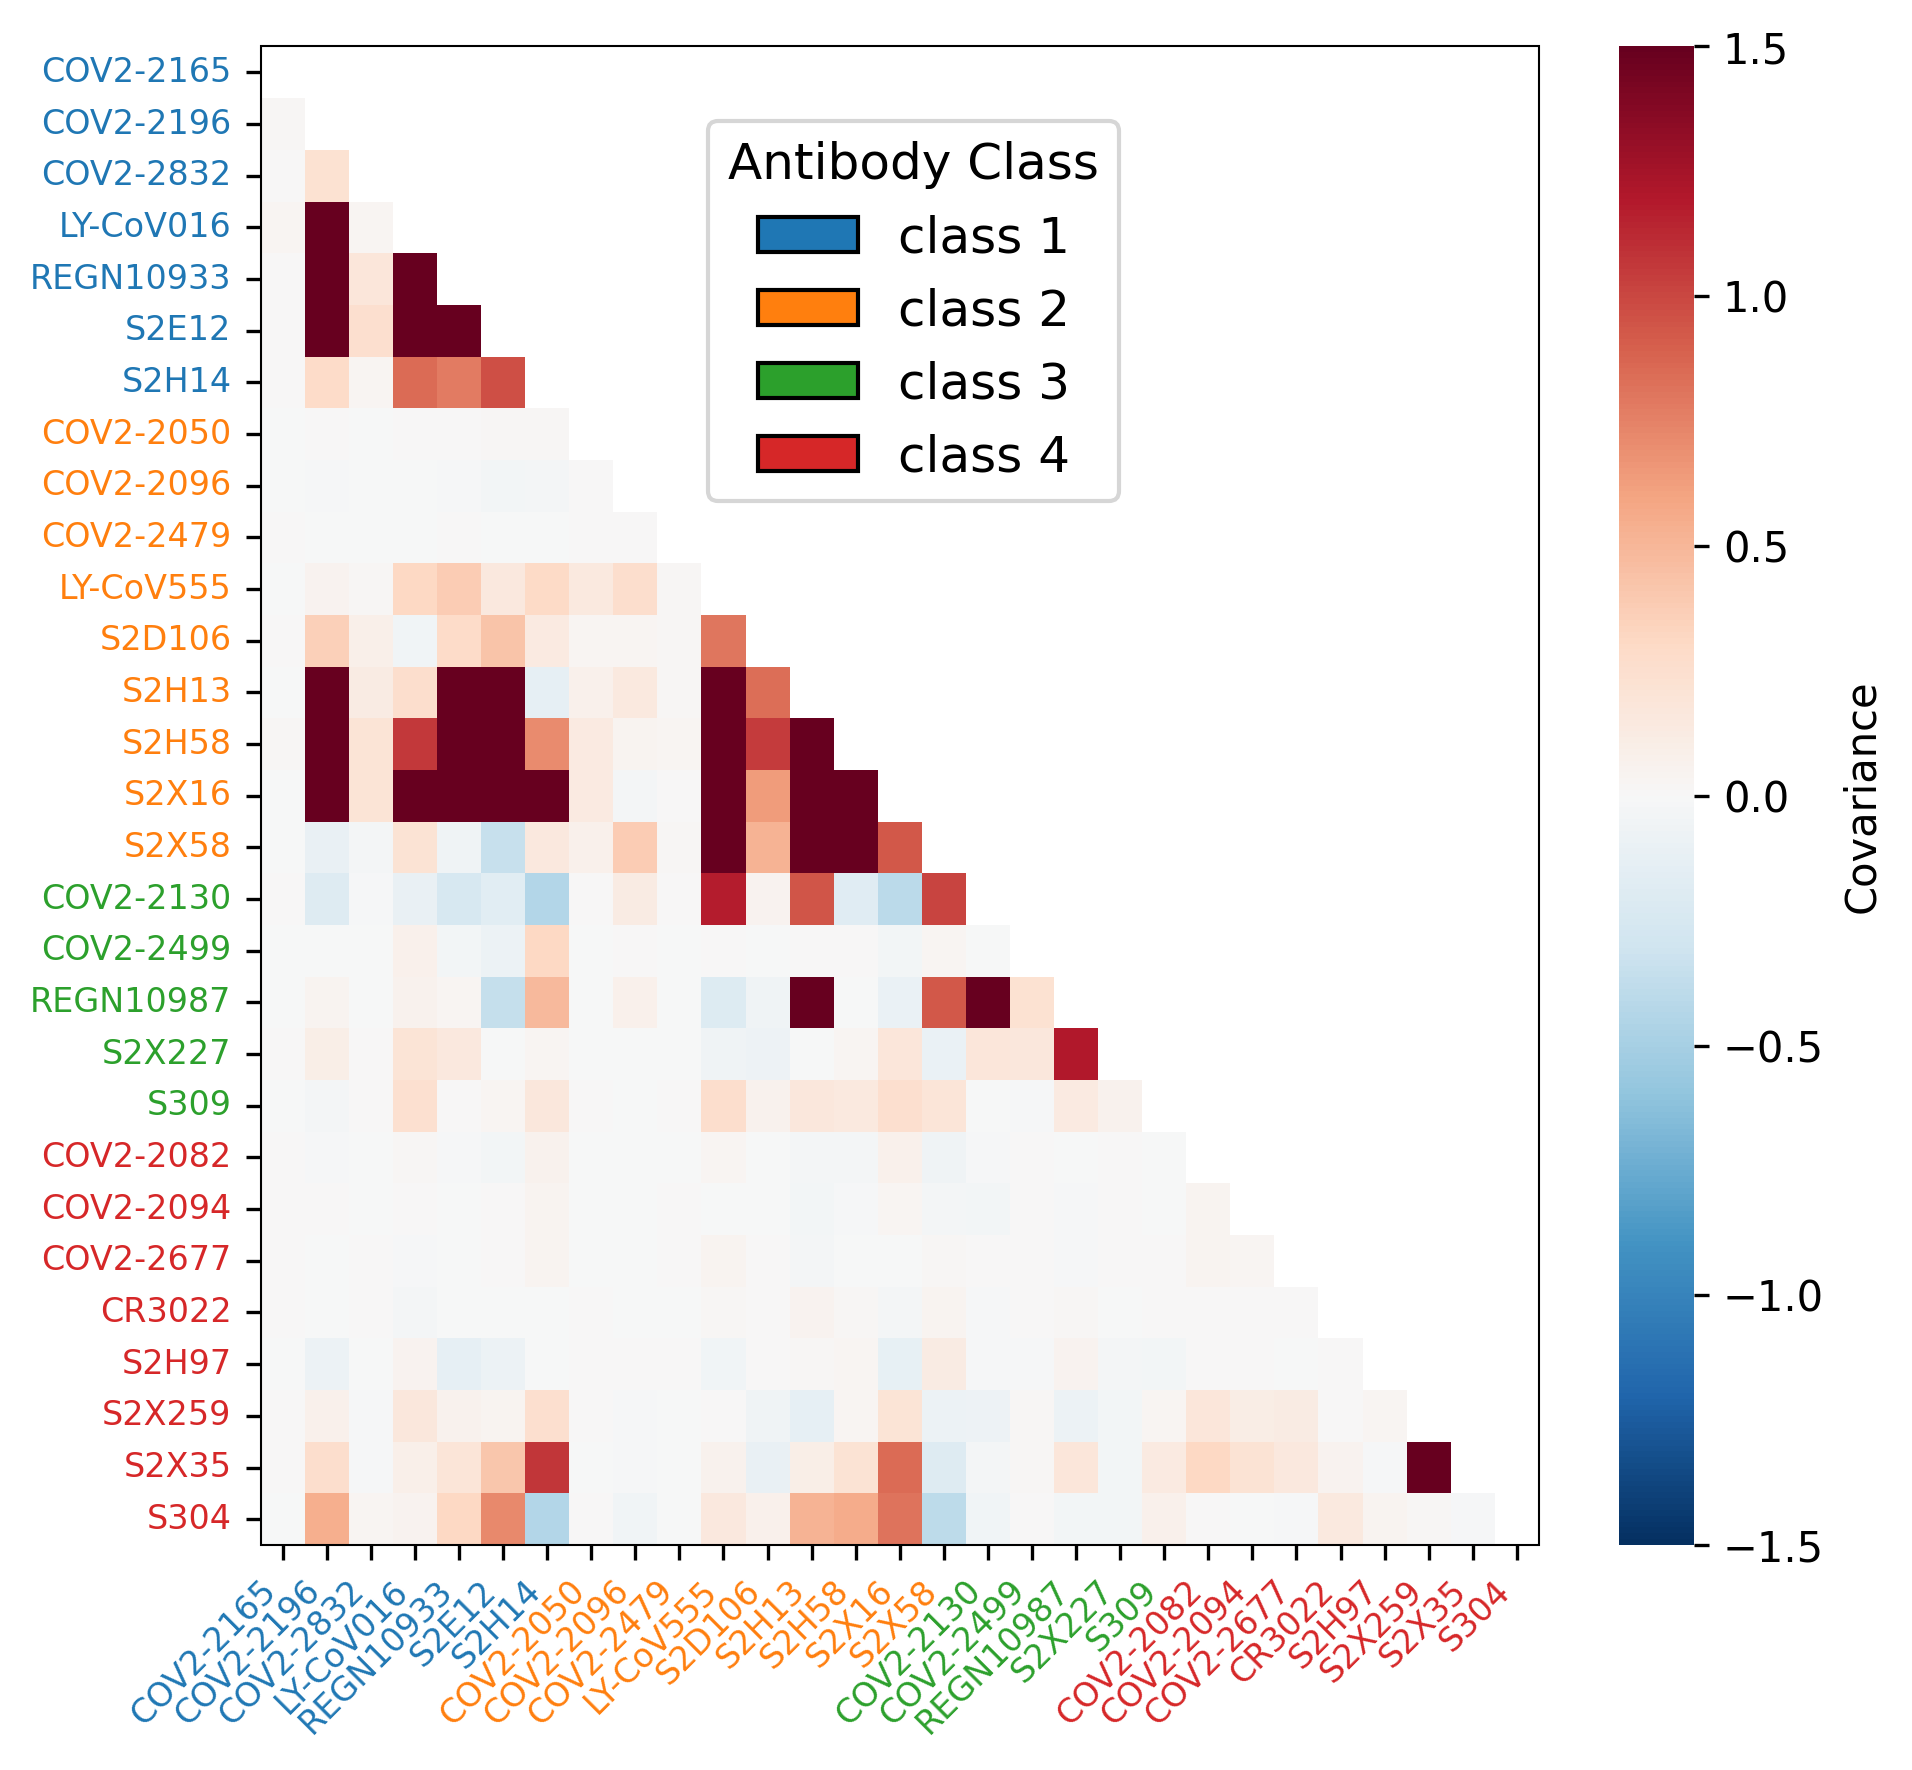

In [ ]:



ab_class_df = pd.DataFrame({'antibody': ab_names})
ab_class_df['class'] = ab_class_df['antibody'].map(class_mapping).fillna('Unknown')

base_order = [f'class {i}' for i in range(1, 6)]
present = list(pd.unique(ab_class_df['class']))
known = [c for c in base_order if c in present]
others = [c for c in present if c not in known and c != 'Unknown']
final_order = known + sorted(others) + (['Unknown'] if 'Unknown' in present else [])

ab_class_df['class'] = pd.Categorical(ab_class_df['class'], categories=final_order, ordered=True)
ab_class_df_sorted = ab_class_df.sort_values(['class', 'antibody'])
sorted_ab_names = ab_class_df_sorted['antibody'].tolist()

class_colors = ab_class_df_sorted['class'].drop_duplicates().reset_index(drop=True)
color_map = {k: f"C{i}" for i, k in enumerate(class_colors)}

df_esc = pd.DataFrame(escapes, columns=ab_names)
cov_matrix = df_esc.cov(min_periods=1)  

sorted_cov = cov_matrix.loc[sorted_ab_names, sorted_ab_names].astype(float)

np.fill_diagonal(sorted_cov.values, np.nan)
mask = np.triu(np.ones_like(sorted_cov, dtype=bool), k=1)

plt.figure(figsize=(6.5, 6), dpi=300)
cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad(color='white')  

vabs = np.nanmax(np.abs(sorted_cov.values))
vmin, vmax = (-vabs, vabs) if np.isfinite(vabs) else (None, None)

ax = sns.heatmap(
    sorted_cov,
    cmap=cmap,
    # vmin=vmin, vmax=vmax,
    mask=mask,
    xticklabels=sorted_ab_names,
    yticklabels=sorted_ab_names,
    cbar_kws={'label': 'Covariance'},
    vmin=-1.5,
    vmax=1.5
)

highlight_abs = set()  
xticks = ax.get_xticklabels()
yticks = ax.get_yticklabels()

for i, tick in enumerate(xticks):
    ab = ab_class_df_sorted.iloc[i]['antibody']
    tick.set_color(color_map[ab_class_df_sorted.iloc[i]['class']])
    if ab in highlight_abs:
        tick.set_fontweight('bold')

for i, tick in enumerate(yticks):
    ab = ab_class_df_sorted.iloc[i]['antibody']
    tick.set_color(color_map[ab_class_df_sorted.iloc[i]['class']])
    if ab in highlight_abs:
        tick.set_fontweight('bold')

ax.set_xticklabels(xticks, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(yticks, rotation=0, ha='right', fontsize=8)

legend_elements = [
    Patch(facecolor=color_map[c], edgecolor='black', label=str(c))
    for c in class_colors
]
ax.legend(
    handles=legend_elements,
    title="Antibody Class",
    bbox_to_anchor=(0.35, 0.95),
    loc='upper left',
    borderaxespad=0.,
    fontsize=12,
    title_fontsize=12
)

n = len(sorted_ab_names)
rect = patches.Rectangle((0, 0), n, n, linewidth=0.5, edgecolor='black',
                         facecolor='none', clip_on=False)
ax.add_patch(rect)

plt.tight_layout()
plt.show()
